# NYC Airbnb Room Type Classification

Dataset: New York City Airon Open Data (Kaggle)

Goal: Predict the room_type of an Airbnb listing (Entire home/apt, Private room, or Shared room) using listing attributes such as price, location, availability, and review activity.

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## 2. Load the Dataset

In [3]:
import os
import kagglehub

# Download dataset
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
source_file = os.path.join(path, "AB_NYC_2019.csv")

# Copy to current directory using the terminal copy command
os.system(f"cp '{source_file}' .")

print("File copied to current folder!")

File copied to current folder!


In [4]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 3. Exploratory Data Analysis (EDA)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
df.shape

(48895, 16)

### 3.1 Missing Values

In [8]:
missing = df.isnull().sum() 
missing[missing > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

### 3.2 Target Variable (room type)

In [9]:
df['room_type'].unique()

<ArrowStringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [10]:
df['room_type'].unique()

<ArrowStringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [11]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

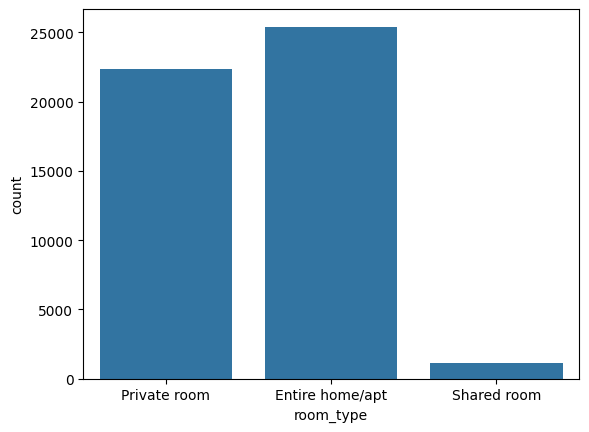

In [12]:
sns.countplot(x = 'room_type', data=df)

**Note:** 

Here we can see that the classes are imbalanced as the shared room is a small minority.

### 3.3 Univariate Analysis (Numeric Features)

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

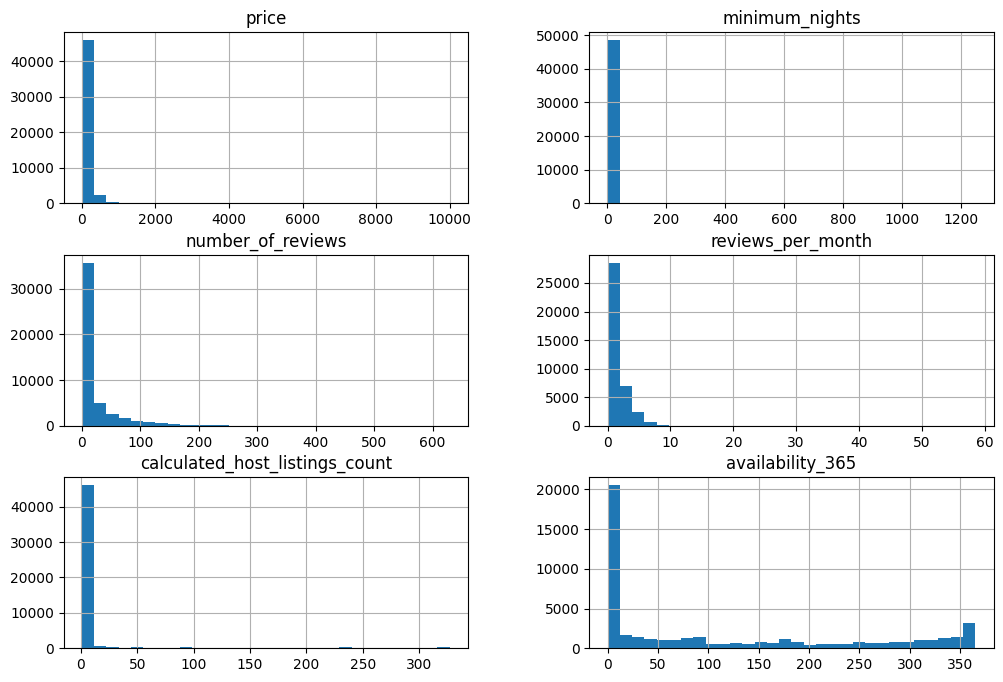

In [13]:
numerical_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count','availability_365']

df[numerical_cols].hist(bins=30, figsize=(12,8))

### 3.4 Univariate Analysis (Categorical Features)

<Axes: xlabel='neighbourhood_group', ylabel='count'>

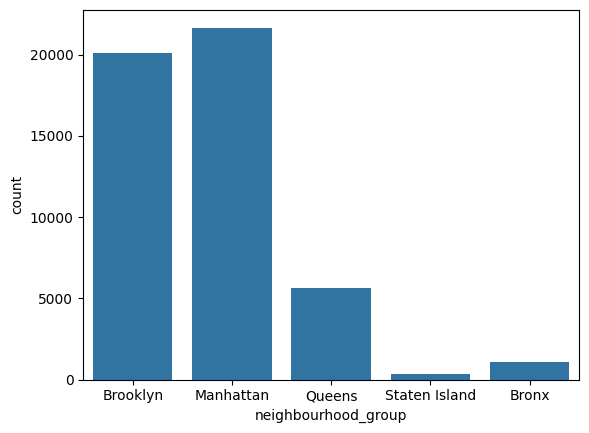

In [14]:
sns.countplot(x='neighbourhood_group', data=df)

### 3.5 Bivariate Analysis (Features vs Target)

<Axes: xlabel='room_type', ylabel='price'>

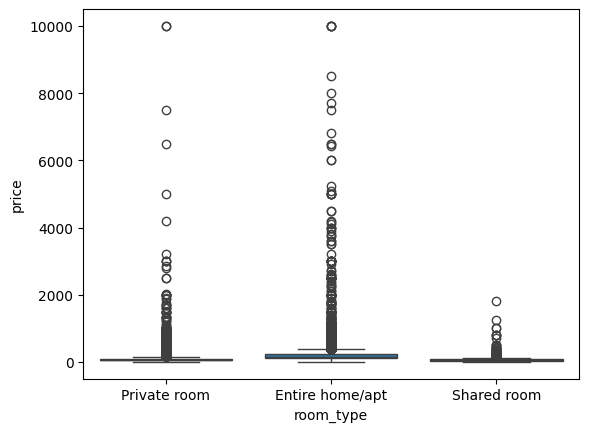

In [15]:
sns.boxplot(x='room_type', y='price', data=df)

<Axes: xlabel='room_type', ylabel='minimum_nights'>

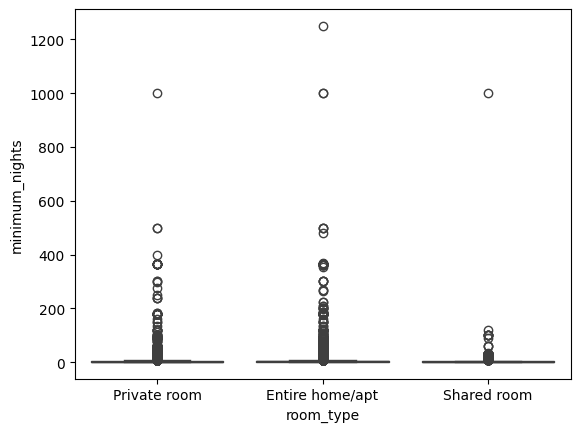

In [17]:
sns.boxplot(x='room_type', y='minimum_nights', data=df)